## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
from torch import optim

### Generate Data

Text(0, 0.5, 'y')

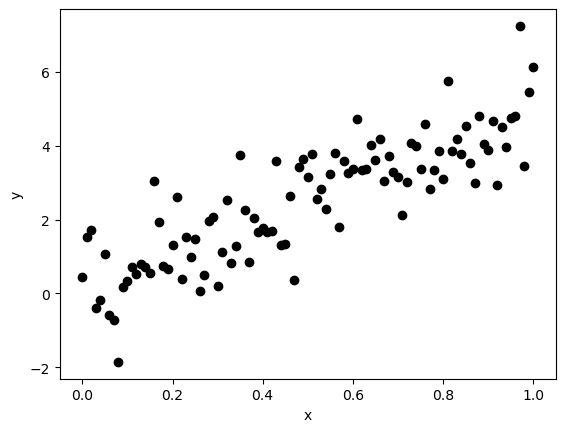

In [2]:
x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

plt.plot(x, y_obs, 'o', color='black')
plt.xlabel("x")
plt.ylabel("y")

## Section 1: Creating a Model and Calculate the Prediction Loss

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neuronal network `model`. |
| `y_pred = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_pred`. |
| `(y_pred-y_obs).square().mean()` | Calculate the mean squared error of the model prediction `y_pred` compared to the observed data `y_obs`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_pred, y_obs)` | Calculates the loss between the output of the network `y_pred` and the observed y-values from the data `y_obs`. |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |

**Demo**: Run the cell below to see a demonstration of how pytorch can be used to do linear regression. We'll learn how to do each of these steps in the following sections.

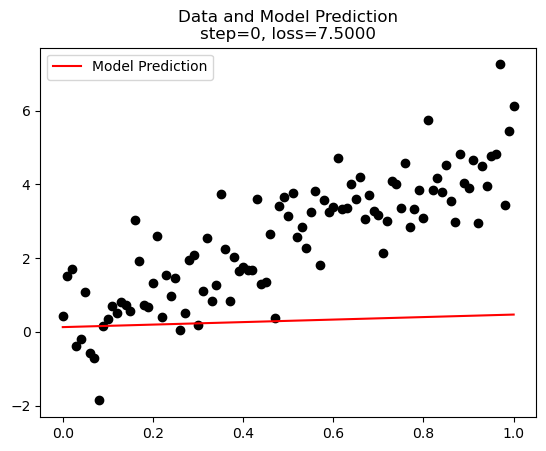

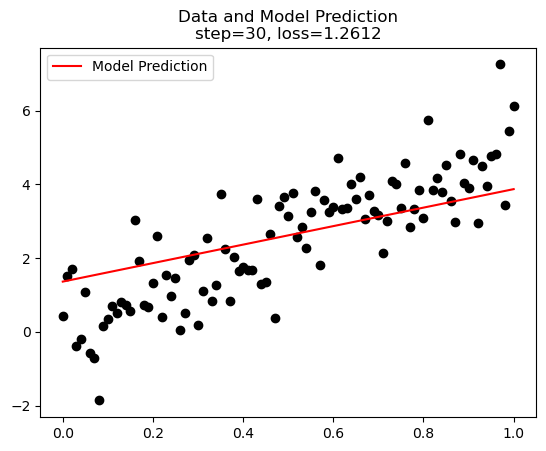

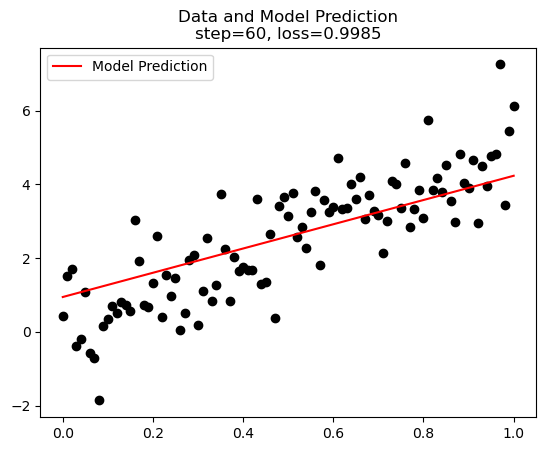

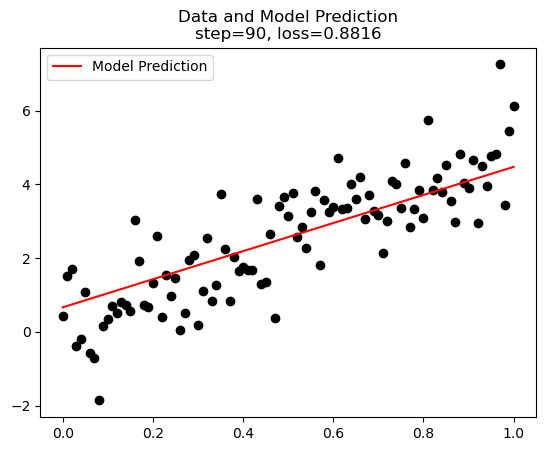

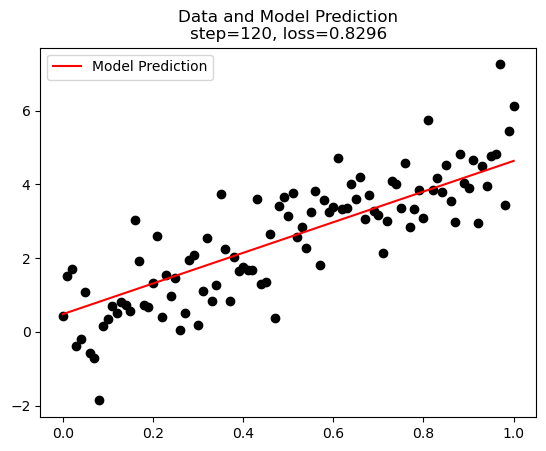

In [43]:
model = nn.Linear(1,1)

optimizer = optim.SGD(model.parameters(), lr=0.1)

for step in range(121):
    optimizer.zero_grad()

    y_pred = model(x)

    loss = (y_pred-y_obs).square().mean()
    if (step % 30) == 0:
        plt.figure()
        plt.title(f"Data and Model Prediction\nstep={step}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model Prediction")
        plt.legend()
    loss.backward()

    optimizer.step()

**Example**: Create a single layer model with 2 input features and 16 output features.

In [62]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create a single layer model with 1 input feature and 8 output features.


In [63]:
nn.Linear(1,8)

Linear(in_features=1, out_features=8, bias=True)

**Exercise**: Create a single layer model with 20 input feature and 2 output features and assign it to a variable called `model`. Print the `model` variable.


In [64]:
model = nn.Linear(20,8)
print(model)

Linear(in_features=20, out_features=8, bias=True)


**Exercise**: Pass the random input generated below to the model.

The output from the model should look like this:

`tensor([-0.5226,  1.6793, -0.3106,  0.6826,  0.0241,  0.1157,  0.5314, -0.3382],
       grad_fn=<ViewBackward0>)`

In [21]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [22]:
model(input)

tensor([ 0.2450, -0.1548,  0.0408, -0.1472,  0.7695, -0.3531, -0.5432,  0.8459],
       grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new random input. Try to pass this input to the model. What does the error message you get say?

In [66]:
torch.manual_seed(2025)
input = torch.randn(25)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990, -0.3729, -0.1594,  0.2836, -1.1234,
         0.9813, -0.2822, -0.2651,  2.7671,  0.8749, -0.1597, -1.5970, -0.7229,
        -0.8230, -0.7882, -2.8070,  0.5447, -1.6047,  0.2632, -1.9616, -0.9576,
        -0.5698])

In [67]:
model(input)

tensor([ 0.3432, -0.5181,  0.6703,  0.3846, -0.6244,  0.4713, -0.2647, -0.0117],
       grad_fn=<ViewBackward0>)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)".

You got this error because the dimensions of the input (1x25) don't match the number of input features in the model (which is 20).

The error message also reveals an important fact about passing inputs through a neural network model: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with 25 input features.

**Exercise**: Create a single layer with 25 input features and 2 output features and assign it to a variable called `model`. Then pass the same random input to the model as in the previous exercise. Did it run through now?

In [68]:
model = nn.Linear(25,8)
model(input)

tensor([-1.1816, -0.2168, -0.4422, -0.1845,  0.3989, -0.8125, -0.1305,  0.0673],
       grad_fn=<ViewBackward0>)

In the cell below a simple model with a single input and output feature is created. Then, the `x` data generated in the setup section is passed to it.

**Exercise**: Calculate the mean square error of the model prediction `y_pred` (compare to the observed data `y_obs`). This is the prediction loss.

**Hint**: See reference table. 

The output should look like this:

`tensor(4.6639, grad_fn=<MeanBackward0>)`

In [69]:
torch.manual_seed(2025)

model = nn.Linear(1,1)
y_pred = model(x)

In [70]:
(y_pred-y_obs).square().mean()

tensor(4.6724, grad_fn=<MeanBackward0>)

**Exercise**: Create a loss function using `torch`'s function `nn.MSELoss()` and assign it to a variable named `loss_function`.

In [98]:
loss_function = nn.MSELoss()

**Exercise**: Calculate the same mean square error loss of the prediction `y_pred` using the loss function you created in the previous exercise.

In [99]:
loss_function(y_pred, y_obs)

tensor(4.6639, grad_fn=<MseLossBackward0>)

**Exercise**: Extract the number from the loss you calculated in the previous exercise from the tensor.

**Hint**: `.item()`

In [101]:
loss_function(y_pred, y_obs).item()

4.663857460021973

## Section 2: Optimize Model Parameters

We have gone through how to create a model, pass input to it to get a prediction, and calculate the loss (error) of the prediction. The next step is to optimize the parameters of the model based on that loss. In the previous session, we did implemented the optimization method called gradient descent ourselves. However, PyTorch provides a package called `optim` that can be used to create optimizer objects that different kinds of optimization methods for us.

| Code | Description |
| --- | --- |
| `optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer. |
| `optim.SGD(net.parameters(), lr=0.01, momentum = 0.99)` | Creates a stochastic gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `optim.Adagrad(net.parameters())` | Creates an adaptive gradient descent optimizer.|
| `optim.ADAM(net.parameters())` | Creates an adaptive moment optimizer .|
| `optimizer = optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer and assigns it to a variable called `optimizer`. |

## Leftovers

## Section 1: Create a Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neural network named `model`. |
| `y_model = model(X_input)` | Pass input `X_input` to a neural network `model` and assign the output to a variable `y_model`. |
| `nn.ReLU()` | Create a rectified linear unit activation function.|
| `nn.Tanh()` | Create a hyperbolic tangent activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in specific order.|

**Exercise**: Create a rectified linear unit activation function.

In [ ]:
model = nn.ReLU()

**Exercise**: Create a hyperbolic tangent activation function.

In [ ]:
nn.Tanh()

**Exercise**: Create a sequence of layers with a rectified linear unit between them. The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create sequence of three linear layers with one hyperbolic tangent activation function and one rectified linear unit between the first and the second linear layer, respectively. The first layer should have two input features and 32 output features, the next linear layer should have 32 input features and 32 output features, the last layer should take in the 32 outputs from the previous layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): Tanh()  <br>
  &nbsp;&nbsp;(0): Linear(in_features=32, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=32, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)